In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from itertools import combinations
from collections import Counter

# Load the cleaned dataset
df = pd.read_csv("../dataset/job_market_analysis.csv")

print("Dataset shape:", df.shape)
print("Column names:")
print(df.columns.tolist())

df.head()

Dataset shape: (2873, 19)
Column names:
['slug', 'company_name', 'title', 'description', 'remote', 'url', 'tags', 'job_types', 'location', 'created_at', 'posted_date', 'posted_year', 'posted_month', 'remote_status', 'job_category', 'experience_level', 'city', 'skills', 'skill_count']


,slug,company_name,title,description,remote,url,tags,job_types,location,created_at,posted_date,posted_year,posted_month,remote_status,job_category,experience_level,city,skills,skill_count
0,software-engineer-price-comparison-portal-berl...,Preiswecker,Software Engineer,Preiswecker is a price comparison portal in Ge...,False,https://www.preiswecker.com/,Software Engineering | E-Commerce,Full-time,Berlin,2026-08-12 06:40:00,2026-08-12,2026,August,On-site,Software & IT,Mid Level / Other,Berlin,[],0
1,senior-product-manager-356253,Verve,Senior Product Manager,Who We Are Verve has created a more efficient ...,False,https://www.arbeitnow.com/jobs/companies/verve...,Product Management,NaN,Unknown,2026-10-01 05:55:15,2026-10-01,2026,October,On-site,Other,Senior,Unknown,['data analysis'],1
2,working-student-launch-operations-parsdorf-bav...,isaraerospace,Working Student Launch Operations (m/f/d),Mission Brief As Working Student Launch Operat...,False,https://www.arbeitnow.com/jobs/companies/isara...,Mission & Launch Operations,NaN,"Parsdorf, Bavaria",2026-10-01 05:55:11,2026-10-01,2026,October,On-site,Other,Mid Level / Other,Parsdorf,[],0
3,senior-mechanical-engineer-parsdorf-bavaria-38...,isaraerospace,Senior Mechanical Engineer (f/m/d),Mission Brief We deliver the half of the rocke...,False,https://www.arbeitnow.com/jobs/companies/isara...,Ground Systems,NaN,"Parsdorf, Bavaria",2026-10-01 05:55:11,2026-10-01,2026,October,On-site,Software & IT,Senior,Parsdorf,[],0
4,mes-process-and-system-engineer-parsdorf-bavar...,isaraerospace,MES Process and System Engineer (m/f/d),Mission Brief&nbsp; Help build the digital man...,False,https://www.arbeitnow.com/jobs/companies/isara...,Production | Operations & Quality,NaN,"Parsdorf, Bavaria",2026-10-01 05:55:11,2026-10-01,2026,October,On-site,Software & IT,Mid Level / Other,Parsdorf,[],0


In [2]:
print("Skills column data type:")
print(df["skills"].dtype)

print("\nFirst 10 skills values:")
print(df["skills"].head(10).to_list())

print("\nMissing skills values:")
print(df["skills"].isna().sum())

Skills column data type:
str

First 10 skills values:
['[]', "['data analysis']", '[]', '[]', '[]', '[]', '[]', "['python']", '[]', '[]']

Missing skills values:
0


In [3]:
# Convert string representations into actual Python lists
df["skills"] = df["skills"].apply(ast.literal_eval)

# Verify the conversion
print("Skills column data type:", df["skills"].dtype)

print("\nFirst 10 parsed skill values:")
print(df["skills"].head(10).to_list())

print("\nTotal job postings:", len(df))
print("Jobs with detected skills:", df["skills"].apply(bool).sum())
print("Jobs without detected skills:", (~df["skills"].apply(bool)).sum())

Skills column data type: object

First 10 parsed skill values:
[[], ['data analysis'], [], [], [], [], [], ['python'], [], []]

Total job postings: 2873
Jobs with detected skills: 974
Jobs without detected skills: 1899


In [4]:
# Flatten all skill lists into one list
all_skills = [
    skill.strip().lower()
    for skill_list in df["skills"]
    for skill in skill_list
    if isinstance(skill, str) and skill.strip()
]

# Count each skill
skill_counts = pd.Series(
    Counter(all_skills),
    name="job_count"
).sort_values(ascending=False)

# Display the top 20 skills
top_skills = skill_counts.head(20).reset_index()
top_skills.columns = ["skill", "job_count"]

print("Total skill mentions:", len(all_skills))
print("Unique detected skills:", len(skill_counts))

display(top_skills)

Total skill mentions: 2077
Unique detected skills: 28


,skill,job_count
0,python,398
1,excel,262
2,sql,204
3,aws,195
4,azure,145
5,java,130
6,machine learning,110
7,javascript,86
8,postgresql,73
9,gcp,60


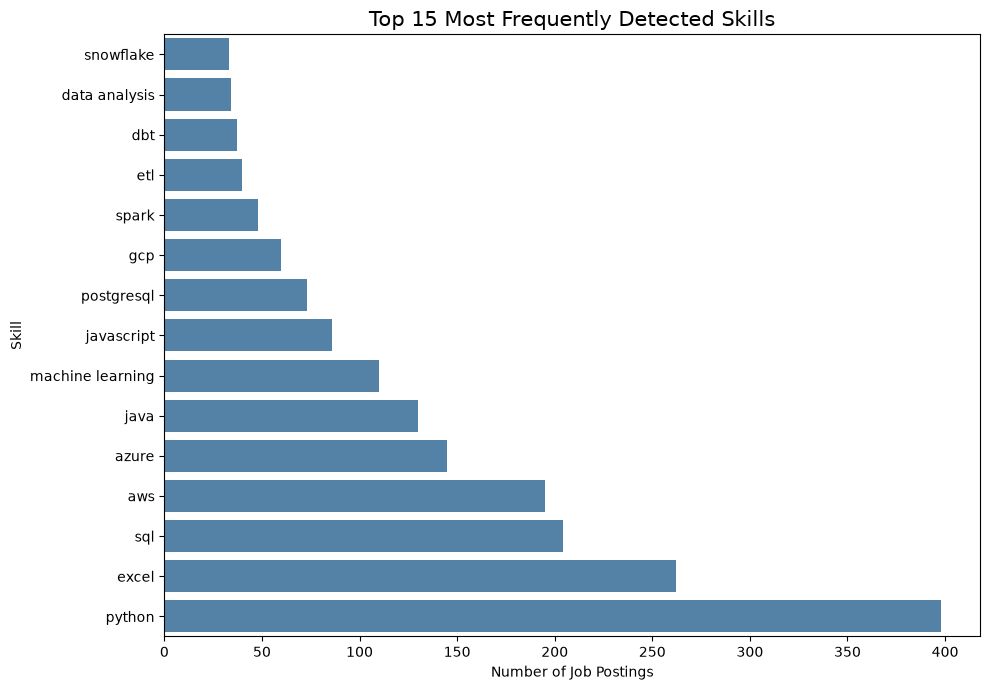

In [5]:
# Select the top 15 detected skills
top_15_skills = top_skills.head(15).sort_values(
    by="job_count",
    ascending=True
)

# Create the chart
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_15_skills,
    x="job_count",
    y="skill",
    color="steelblue"
)

plt.title("Top 15 Most Frequently Detected Skills", fontsize=15)
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()

plt.savefig(
    "../visuals/top_15_detected_skills.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
# Calculate percentage of all job postings mentioning each skill
top_skills["job_posting_percentage"] = (
    top_skills["job_count"] / len(df) * 100
).round(2)

display(top_skills.head(15))

,skill,job_count,job_posting_percentage
0,python,398,13.85
1,excel,262,9.12
2,sql,204,7.10
3,aws,195,6.79
4,azure,145,5.05
5,java,130,4.52
6,machine learning,110,3.83
7,javascript,86,2.99
8,postgresql,73,2.54
9,gcp,60,2.09


In [7]:
# Explode the skills list so each skill gets its own row
skills_by_category = df[
    ["job_category", "skills"]
].explode("skills")

# Remove empty or missing skills
skills_by_category = skills_by_category[
    skills_by_category["skills"].apply(
        lambda x: isinstance(x, str) and bool(x.strip())
    )
].copy()

# Standardize skill names
skills_by_category["skills"] = (
    skills_by_category["skills"].str.strip().str.lower()
)

# Count skill mentions by job category
category_skill_counts = (
    skills_by_category
    .groupby(["job_category", "skills"])
    .size()
    .reset_index(name="job_count")
    .sort_values(
        ["job_category", "job_count"],
        ascending=[True, False]
    )
)

# Display the top 10 skills in each category
top_skills_by_category = (
    category_skill_counts
    .groupby("job_category")
    .head(10)
)

display(top_skills_by_category)

,job_category,skills,job_count
19,Data & Analytics,python,90
24,Data & Analytics,sql,83
0,Data & Analytics,aws,40
12,Data & Analytics,machine learning,35
5,Data & Analytics,dbt,31
6,Data & Analytics,etl,29
1,Data & Analytics,azure,26
23,Data & Analytics,spark,23
7,Data & Analytics,excel,21
22,Data & Analytics,snowflake,20


In [8]:
skills_by_experience = df[
    ["experience_level", "skills"]
].explode("skills")

skills_by_experience = skills_by_experience[
    skills_by_experience["skills"].apply(
        lambda x: isinstance(x, str) and bool(x.strip())
    )
].copy()

skills_by_experience["skills"] = (
    skills_by_experience["skills"].str.strip().str.lower()
)

experience_skill_counts = (
    skills_by_experience
    .groupby(["experience_level", "skills"])
    .size()
    .reset_index(name="job_count")
    .sort_values(
        ["experience_level", "job_count"],
        ascending=[True, False]
    )
)

top_skills_by_experience = (
    experience_skill_counts
    .groupby("experience_level")
    .head(10)
)

display(top_skills_by_experience)

,experience_level,skills,job_count
6,Entry Level,excel,20
15,Entry Level,python,18
18,Entry Level,sql,10
8,Entry Level,javascript,7
0,Entry Level,aws,4
1,Entry Level,azure,4
5,Entry Level,etl,3
7,Entry Level,java,3
9,Entry Level,machine learning,2
14,Entry Level,power bi,2


In [9]:
# Count pairs of skills appearing in the same job posting

pair_counts = Counter()

for skill_list in df["skills"]:
    # Normalize and remove duplicate skills within each posting
    unique_skills = sorted({
        skill.strip().lower()
        for skill in skill_list
        if isinstance(skill, str) and skill.strip()
    })

    # Generate every pair of skills in this posting
    for pair in combinations(unique_skills, 2):
        pair_counts[pair] += 1

# Convert results into a DataFrame
skill_pairs = pd.DataFrame(
    [
        {
            "skill_1": pair[0],
            "skill_2": pair[1],
            "job_count": count
        }
        for pair, count in pair_counts.items()
    ]
)

skill_pairs = skill_pairs.sort_values(
    "job_count",
    ascending=False
).reset_index(drop=True)

print("Unique skill combinations:", len(skill_pairs))
display(skill_pairs.head(20))

Unique skill combinations: 248


,skill_1,skill_2,job_count
0,aws,python,111
1,python,sql,108
2,aws,azure,83
3,machine learning,python,76
4,azure,python,64
5,aws,gcp,53
6,aws,sql,52
7,java,python,50
8,azure,gcp,42
9,azure,sql,41


In [10]:
# Combinations relevant to analytics and BI roles
target_pairs = [
    ("python", "sql"),
    ("excel", "sql"),
    ("power bi", "sql"),
    ("python", "power bi"),
    ("excel", "power bi"),
    ("python", "excel"),
    ("postgresql", "python"),
    ("postgresql", "sql")
]

pair_lookup = {
    (row.skill_1, row.skill_2): row.job_count
    for row in skill_pairs.itertuples(index=False)
}

target_pair_results = pd.DataFrame([
    {
        "skill_1": skill_1,
        "skill_2": skill_2,
        "job_count": pair_lookup.get(
            tuple(sorted((skill_1, skill_2))), 0
        )
    }
    for skill_1, skill_2 in target_pairs
]).sort_values("job_count", ascending=False)

display(target_pair_results)

,skill_1,skill_2,job_count
0,python,sql,108
6,postgresql,python,30
5,python,excel,22
1,excel,sql,20
7,postgresql,sql,20
2,power bi,sql,18
4,excel,power bi,16
3,python,power bi,9


In [11]:
# Core skills relevant to Data Analyst roles
core_skills = [
    "sql",
    "python",
    "excel",
    "power bi",
    "tableau",
    "postgresql",
    "r",
    "statistics",
    "data analysis",
    "machine learning"
]

core_skill_analysis = (
    skill_counts
    .reindex(core_skills, fill_value=0)
    .rename_axis("skill")
    .reset_index(name="job_count")
    .sort_values("job_count", ascending=False)
)

core_skill_analysis["job_posting_percentage"] = (
    core_skill_analysis["job_count"] / len(df) * 100
).round(2)

display(core_skill_analysis)

,skill,job_count,job_posting_percentage
1,python,398,13.85
2,excel,262,9.12
0,sql,204,7.10
9,machine learning,110,3.83
5,postgresql,73,2.54
8,data analysis,34,1.18
3,power bi,33,1.15
4,tableau,24,0.84
7,statistics,23,0.80
6,r,0,0.00


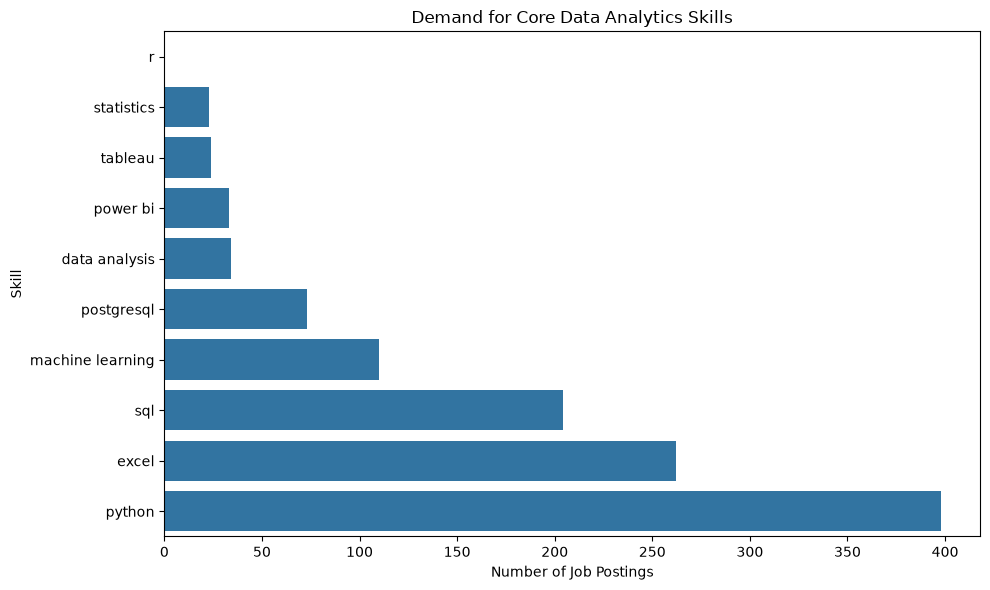

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = core_skill_analysis.sort_values("job_count")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="job_count",
    y="skill"
)

plt.title("Demand for Core Data Analytics Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig("../visuals/core_data_analytics_skills.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [13]:
from pathlib import Path

output_dir = Path("../dataset")
output_dir.mkdir(parents=True, exist_ok=True)

top_skills.to_csv(output_dir / "skill_frequency.csv", index=False)
top_skills_by_category.to_csv(
    output_dir / "skills_by_category.csv", index=False
)
top_skills_by_experience.to_csv(
    output_dir / "skills_by_experience.csv", index=False
)
skill_pairs.to_csv(
    output_dir / "skill_combinations.csv", index=False
)
target_pair_results.to_csv(
    output_dir / "data_analyst_skill_combinations.csv", index=False
)
core_skill_analysis.to_csv(
    output_dir / "core_data_analytics_skills.csv", index=False
)

print("Skill analysis datasets exported successfully.")

Skill analysis datasets exported successfully.
